# 07 - 融资融券与指数数据

本 Notebook 完成以下任务：
1. 融资融券余额采集 → `stock_margin`
2. 指数日线采集（上证/深证/创业板/沪深300/中证500） → `index_daily`
3. 数据验证

---

## 设计方案

### 融资融券
- 接口：`margin`，按日期拉取全市场
- 增量机制：检查 `stock_margin` 中缺失的交易日

### 指数日线
- 接口：`index_daily`，按指数代码 + 日期范围
- 默认覆盖 5 个核心指数：上证、深证成指、创业板指、沪深300、中证500
- 增量机制：同日线行情

## 1. 指数日线采集

In [1]:
from invest_model.db import get_engine
from invest_model.sources.tushare_client import TushareClient
from invest_model.collectors.market_collector import MarketCollector, DEFAULT_INDICES

engine = get_engine()
ts_client = TushareClient()
collector = MarketCollector(ts_client, engine)

print(f"采集指数: {DEFAULT_INDICES}")
results = collector.collect_index_daily()

for code, count in results.items():
    print(f"  {code}: {count} 条")

10:30:07 | INFO    | Tushare 客户端初始化完成


采集指数: ['000001.SH', '399001.SZ', '399006.SZ', '000300.SH', '000905.SH']


10:30:08 | INFO    | 指数 000001.SH: 1209 条
10:30:08 | INFO    | 指数 399001.SZ: 1209 条
10:30:09 | INFO    | 指数 399006.SZ: 1209 条
10:30:09 | INFO    | 指数 000300.SH: 1209 条
10:30:10 | INFO    | 指数 000905.SH: 1209 条


  000001.SH: 1209 条
  399001.SZ: 1209 条
  399006.SZ: 1209 条
  000300.SH: 1209 条
  000905.SH: 1209 条


## 2. 融资融券（增量采集）

In [ ]:
n = collector.collect_margin_incremental()
print(f"融资融券采集完成: {n} 条")

10:30:10 | INFO    | 融资融券缺失 1210 天
10:30:10 | WARNING | 融资融券 20210409: (pymysql.err.OperationalError) (1364, "Field 'code' doesn't have a default value")
[SQL: 
            INSERT INTO stock_margin (`trade_date`, `rzye`, `rqye`, `rzmre`, `rqyl`, `rzche`)
            VALUES (%(trade_date)s, %(rzye)s, %(rqye)s, %(rzmre)s, %(rqyl)s, %(rzche)s)
            ON DUPLICATE KEY UPDATE `rzye`=VALUES(`rzye`), `rqye`=VALUES(`rqye`), `rzmre`=VALUES(`rzmre`), `rqyl`=VALUES(`rqyl`), `rzche`=VALUES(`rzche`)
        ]
[parameters: [{'trade_date': '20210409', 'rzye': 799847556152.0, 'rqye': 90402211447.0, 'rzmre': 27075190407.0, 'rqyl': 7691643191.0, 'rzche': 27557216389.0}, {'trade_date': '20210409', 'rzye': 715000419011.0, 'rqye': 58105624800.0, 'rzmre': 27866716873.0, 'rqyl': 3314715814.0, 'rzche': 29729718576.0}]]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
10:30:10 | WARNING | 融资融券 20210412: (pymysql.err.OperationalError) (1364, "Field 'code' doesn't have a default value")
[SQL: 
 

## 3. 数据验证

In [ ]:
from invest_model.repositories.market_repo import MarketRepository

market_repo = MarketRepository(engine)

# 上证指数近期
idx = market_repo.get_index_daily("000001.SH", "20260301", "20260406")
print(f"上证指数近期 ({len(idx)} 条):")
print(idx.tail(10).to_string(index=False))

上证指数近期 (25 条):
     code trade_date    open    high     low   close  pre_close  change  pct_chg volume       amount          created_at
000001.SH   20260323 3904.95 3906.62 3794.68 3813.28    3957.05 -143.77  -3.6333   None 1086248286.0 2026-04-07 17:24:56
000001.SH   20260324 3849.63 3881.42 3807.99 3881.28    3813.28   68.00   1.7832   None  931418842.7 2026-04-07 17:24:56
000001.SH   20260325 3892.27 3933.06 3891.82 3931.84    3881.28   50.56   1.3026   None  967854261.2 2026-04-07 17:24:56
000001.SH   20260326 3924.96 3937.10 3880.57 3889.08    3931.84  -42.75  -1.0874   None  848361335.1 2026-04-07 17:24:56
000001.SH   20260327 3852.09 3924.11 3852.09 3913.72    3889.08   24.64   0.6336   None  799696430.9 2026-04-07 17:24:56
000001.SH   20260330 3884.28 3924.29 3872.78 3923.29    3913.72    9.56   0.2443   None  839822434.7 2026-04-07 17:24:56
000001.SH   20260331 3924.07 3948.81 3891.86 3891.86    3923.29  -31.43  -0.8010   None  891945339.6 2026-04-07 17:24:56
000001.SH   20260

In [ ]:
# 各指数数据量统计
stats = market_repo.read_sql(
    "SELECT code, COUNT(*) as cnt, MIN(trade_date) as start_date, MAX(trade_date) as end_date "
    "FROM index_daily GROUP BY code ORDER BY code"
)
print("指数数据统计:")
print(stats.to_string(index=False))

指数数据统计:
     code  cnt start_date end_date
000001.SH 1210   20210408 20260407
000300.SH 1210   20210408 20260407
000905.SH 1210   20210408 20260407
399001.SZ 1210   20210408 20260407
399006.SZ 1210   20210408 20260407


## 4. 主要指数归一化对比（基期=100）

将上证、深证成指、创业板指收盘价除以各自序列首日，便于对比相对强弱。

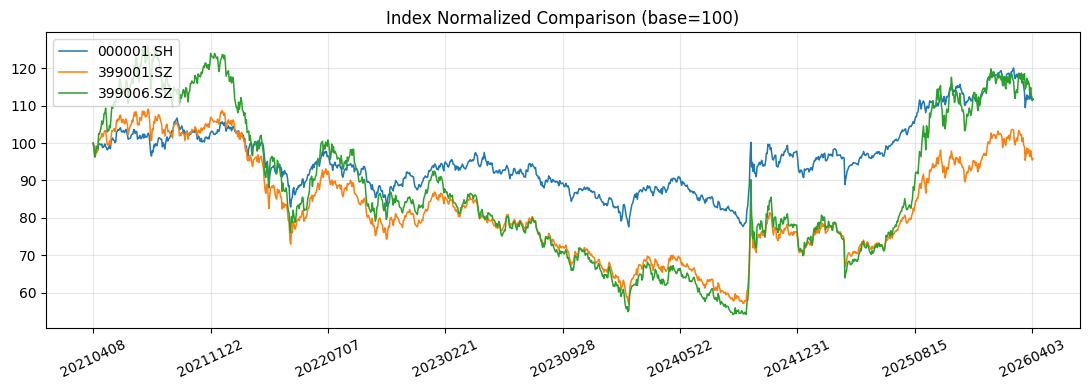

In [ ]:
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt

compare_codes = ["000001.SH", "399001.SZ", "399006.SZ"]
fig, ax = plt.subplots(figsize=(11, 4))
max_len = 0
for c in compare_codes:
    idx_df = market_repo.get_index_daily(c, "20200101", "20991231")
    if idx_df.empty or "close" not in idx_df.columns:
        continue
    idx_df = idx_df.sort_values("trade_date").dropna(subset=["close"]).reset_index(drop=True)
    close = idx_df["close"].astype(float)
    norm = close / close.iloc[0] * 100
    x = range(len(idx_df))
    ax.plot(x, norm, label=c, linewidth=1.1)
    if len(idx_df) > max_len:
        max_len = len(idx_df)
        ref_dates = idx_df["trade_date"].astype(str)
step = max(1, max_len // 8)
ax.set_xticks(list(range(max_len))[::step])
ax.set_xticklabels(ref_dates.iloc[::step], rotation=25)
ax.set_title("Index Normalized Comparison (base=100)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 完成

市场数据采集完毕，继续 `08_validation.ipynb` 进行数据质量校验。